# Conditional WGAN_GP 
Andrew E. Davidson aedavids@ucsc.edu 8/29/24  

Copyright (c) 2020-2023, Regents of the University of California All rights reserved.   https://polyformproject.org/licenses/noncommercial/1.0.0

This notebook's purpose is to ensure the correctness of our PyTorch implementation. Our test generator learns to create points on a parabola. We have an infinite number of real training examples and can easily verify the results with a simple plot.

This notebook add conditional generation to the WGAN_GP Note book. We add a 1-hot encoding to the generators input noise vector. We append a 1-hot encoding to the input to the critic. We do not need to change the discriminator or the generator. Only the training loop changes.


**ref:**  
- WGAN_GP.ipynb
- [pytorch doc](https://pytorch.org/docs/stable/index.html)
- basicPytorchGAN.ipynb


In [1]:
import ipynbname
import matplotlib.pyplot as plt

import numpy as np
from numpy import hstack
from numpy import zeros
from numpy import ones
import psutil # provides process stats
# from numpy.random import rand
# from numpy.random import randn
import os

# by default keras use tensorflow as backend
import torch
print(f'torch.__version__: {torch.__version__}')

# Set random number generation for testing purposes, 
from torch import nn
torch.manual_seed(0)
rng = np.random.default_rng(seed=42)


import torch.nn.functional as F

# tqdm provides progress bars for loops and iterables.
from tqdm.auto import tqdm

# class that helps you efficiently load and iterate over your dataset
# during training or inference
# we do not need this for our toy example
from torch.utils.data import DataLoader

notebookName = ipynbname.name()
notebookPath = ipynbname.path()
notebookDir = os.path.dirname(notebookPath)

outDir = f'{notebookDir}/{notebookName}.out'
imgOut = f'{outDir}/img'
os.makedirs(imgOut, exist_ok=True) 
print(f'imgOut:\n{imgOut}')

torch.__version__: 2.5.1.post102
imgOut:
/private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/conditionalWGAN_GP.out/img


## Create models

In [2]:
def generateLatentPoints(latentDimensions : int = 5, 
                         n : int = 100, device : str = 'cpu' ) -> torch.Tensor :
    '''
    generate points in latent space as input for the generator

    latentDimensions:
        the number of dimensions for the generator's input vector

    n the number of vectors to generate

    device. either 'cpu' or 'cuda', default 'cpu'


    returns a tensor
    '''
    # generate points in the latent space
    #xInput = randn(latentDimensions * n)
    xInput = rng.standard_normal(latentDimensions * n)
    
    # reshape into a batch of inputs for the network
    xInput = xInput.reshape(n, latentDimensions)
    
    ret = torch.Tensor( xInput ).to( device )
    
    return ret

def testGenerateLatentPoints():
    tglp = generateLatentPoints(latentDimensions=5, n=3 )
    print(f'tglp.device : {str(tglp.device)}')
    print( tglp )
    print( tglp.shape )

testGenerateLatentPoints()

tglp.device : cpu
tensor([[ 0.3047, -1.0400,  0.7505,  0.9406, -1.9510],
        [-1.3022,  0.1278, -0.3162, -0.0168, -0.8530],
        [ 0.8794,  0.7778,  0.0660,  1.1272,  0.4675]])
torch.Size([3, 5])


In [3]:
class ParabolaGenerator( nn.Module ):
    def __init__( self, latentDim : int, nOutputs : int = 2 ) :
        '''
        arguments:
            latentDim: the length of the noise input vector

            nOutputs : the length of the output layers vector. Default = 2
        '''
        super().__init__()


        # keras
        # model.add(Dense(15, activation='relu', kernel_initializer='he_uniform', input_dim=latent_dim))
        # model.add(Dense(n_outputs, activation='linear'))
        
        self.model = nn.Sequential(
            nn.Linear(latentDim, 15),
            nn.ReLU(),

            # 11/12 add more capacity
            nn.Linear(15, 30),
            nn.ReLU(), 
            
            # nn.Linear(15, nOutputs),
            nn.Linear(30, nOutputs),
        )
        # Initialize weights
        # nn.init.kaiming_uniform_(self.model[0].weight, nonlinearity='relu')
        # nn.init.zeros_(self.model[0].bias)
        # nn.init.kaiming_uniform_(self.model[2].weight, nonlinearity='linear')
        # nn.init.zeros_(self.model[2].bias)
        
        nn.init.kaiming_uniform_(self.model[0].weight, nonlinearity='relu')
        nn.init.zeros_(self.model[0].bias)

        nn.init.kaiming_uniform_(self.model[2].weight, nonlinearity='relu')
        nn.init.zeros_(self.model[2].bias)        
        
        nn.init.kaiming_uniform_(self.model[4].weight, nonlinearity='linear')
        nn.init.zeros_(self.model[4].bias)    

    def forward( self, noise : torch.Tensor ):
        '''
            noise should be the value returned by generateLatentPoints()
        '''
        ret = self.model( noise )
        return ret

def testParabolaGenerator():
    zDim = 5
    currentBatchSize = 3
    noiseVector = generateLatentPoints(zDim, currentBatchSize)
    generator = ParabolaGenerator(zDim, 2)
    fakeSamples = generator( noiseVector )
    print(f'fakeSamples:\n{fakeSamples}')

testParabolaGenerator()

fakeSamples:
tensor([[-0.3779,  0.4022],
        [-0.3318, -0.3632],
        [-0.0767,  0.1959]], grad_fn=<AddmmBackward0>)


In [4]:
class ParabolaCritic( nn.Module ):
    def __init__( self, inputSize : int = 2 ):
        '''
            inputSize, the length of the generated vectors
        '''
        super().__init__()
        
        self.model = nn.Sequential(
            nn.Linear(inputSize, 25),
            nn.ReLU(),
            
            nn.Linear(25, 40),
            # 11/12/24 add capacity
            nn.ReLU(),

            nn.Linear(40, 1),

            # output layer should be  1-Lipschitz continuous
            #nn.Sigmoid()
            # LeakyReLU default: negative_slope=0.01
            # 0.02 0.04
            nn.LeakyReLU(negative_slope=0.03, inplace=True)  # LeakyReLU instead of Sigmoid

        )
        
        nn.init.kaiming_uniform_(self.model[0].weight, nonlinearity='relu')
        nn.init.zeros_(self.model[0].bias)

        nn.init.kaiming_uniform_(self.model[2].weight, nonlinearity='relu')
        nn.init.zeros_(self.model[2].bias)        
        
        nn.init.kaiming_uniform_(self.model[4].weight, nonlinearity='leaky_relu')
        nn.init.zeros_(self.model[4].bias)    

    def forward( self, X : torch.Tensor ):
        ret = self.model( X )
        return ret

def testParabolaCritic() :
    inputSize = 2
    discriminator = ParabolaCritic( inputSize )
    numTest = 3
    testInput = torch.randn( numTest, inputSize )
    predictions = discriminator( testInput )
    print(f'\npredictions :\n{predictions}')

testParabolaCritic()


predictions :
tensor([[-0.0091],
        [-0.0287],
        [-0.0368]], grad_fn=<LeakyReluBackward1>)


## Data Utilities
function to generate real and fake tensors

### Real Sample utilities

In [5]:
   def getOneHotLabels(labels : torch.Tensor, nClasses : int):
    '''
    Function for creating one-hot vectors for the labels, returns a tensor of shape (?, num_classes).
    Parameters:
        labels: 
            tensor of labels 
        
        nClasses: 
            the total number of classes in the dataset, an integer scalar
    '''
    return F.one_hot(labels, nClasses)

def testGetOneHotLabels():
    l = np.array( [[0,1,2, 0, 2, 1, 1,4]] )
    
    labels = torch.Tensor( l ).long() # must be an index, not a float
    
    print(f'labels.shape : {labels.shape}\n labels:\n{labels}')

    # print works better with numpy values        
    oneHots = getOneHotLabels(labels, nClasses=5)
    print(f'\noneHots.shape : {oneHots.shape} \noneHots:\n{oneHots.numpy()}')


testGetOneHotLabels()

labels.shape : torch.Size([1, 8])
 labels:
tensor([[0, 1, 2, 0, 2, 1, 1, 4]])

oneHots.shape : torch.Size([1, 8, 5]) 
oneHots:
[[[1 0 0 0 0]
  [0 1 0 0 0]
  [0 0 1 0 0]
  [1 0 0 0 0]
  [0 0 1 0 0]
  [0 1 0 0 0]
  [0 1 0 0 0]
  [0 0 0 0 1]]]


In [6]:
def generateRealSamples( n : int, device : str = 'cpu' ) -> tuple[torch.Tensor, torch.Tensor] :
    '''
    generate n real parabola samples with class labels

    arguments :
        n : number of examples to generated

        device. either 'cpu' or 'cuda', default 'cpu'

    Returns 2 Tensor
        X, y i.e. (realSamples, realLabels)
            X[0] = x
            X[1] = x^2. e.g. f(x) = x^2

        y = 1, ie real
    '''
    # generate inputs in range [-0.5, 0.5]
    #X1 = rand(n) - 0.5
    X1 = rng.random(n) - 0.5
    
    # generate outputs X^2
    X2 = X1 * X1
    
    # stack arrays
    X1 = X1.reshape(n, 1)
    X2 = X2.reshape(n, 1)
    X = hstack((X1, X2))
    
    # generate class labels
    y = ones((n, 1))

    # numpy dtype defaults to float64
    # pytorch default is float32
    realSamples = torch.tensor( X, dtype=torch.float32 ).to( device )
    realLabels = torch.tensor( y, dtype=torch.float32 ).to( device )
    
    return (realSamples, realLabels)

def testGenerateRealSamples() :
    X, y = generateRealSamples( n = 10 ) 
    print(f'X.device : {str(X.device)}')
    print( f'X.shape: {X.shape} rank : {len(X.shape)} num elements : {X.numel()}' )
    print( X )

    print(f'\ny.device : {str(y.device)}')
    print( f'y.shape: {y.shape} rank : {len(y.shape)} num elements : {y.numel()}' )
    print ( y) 

testGenerateRealSamples()

X.device : cpu
X.shape: torch.Size([10, 2]) rank : 2 num elements : 20
tensor([[ 0.2448,  0.0599],
        [ 0.4675,  0.2186],
        [-0.1742,  0.0303],
        [-0.1295,  0.0168],
        [-0.0304,  0.0009],
        [-0.3105,  0.0964],
        [-0.3701,  0.1370],
        [-0.0243,  0.0006],
        [-0.2731,  0.0746],
        [ 0.1698,  0.0288]])

y.device : cpu
y.shape: torch.Size([10, 1]) rank : 2 num elements : 10
tensor([[1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.]])


In [7]:
def generateOneHotReals(
            n : int, 
            category : int, 
            nCategories : int,
            device : str = 'cpu'
    ) -> tuple[torch.Tensor, torch.Tensor] :
    '''

    arguments:
        n : 
            the number of samples to generate
    
        category: 
            the label: an integer in the range [0, nCategories - 1]
        
        nCategories: 
            the total number of classes in the dataset, an integer scalar    
        
        device :
            default 'cpu'

        returns 
            first tensor is real values concontanted wiht a 1 hot encoding for category
            second tenor is the label tensor
    '''

    # labels is a tensor of "1" i.e. all the samples are real
    real, labels = generateRealSamples( n )
    intercept = category % nCategories

    # real[:,0] = x
    # real[:,1] = f(x) == x^2
    real[:,1] += intercept
    
    l = torch.tensor( [category  for i in range(n)] ).long()
    oneHots = getOneHotLabels(l, nCategories)

    ret = torch.cat( [real, oneHots], dim = 1 )

    return (ret, labels)

def testGenerateOneHotReals():
    n = 2
    category = 2
    nCategories = 3
    realOneHots, labels = generateOneHotReals(n, category, nCategories)
    print(f'labels:\n{labels}')
    print(f'category : {category}, nCategories : {nCategories} realOneHots:\n{realOneHots}')
    print(f'type(realOneHots) {type(realOneHots)} type(labels) : {type(labels)}')

testGenerateOneHotReals()

labels:
tensor([[1.],
        [1.]])
category : 2, nCategories : 3 realOneHots:
tensor([[-0.0628,  2.0039,  0.0000,  0.0000,  1.0000],
        [ 0.3327,  2.1107,  0.0000,  0.0000,  1.0000]])
type(realOneHots) <class 'torch.Tensor'> type(labels) : <class 'torch.Tensor'>


In [8]:
def generateOneHotRealBalancedBatch(
                n : int, 
                nCategories : int,
                device : str = 'cpu'
    ) -> tuple[torch.Tensor, torch.Tensor] :
    '''
    for c in nCategories:
        create real sample concatenated with oneHotEncoding for c

    arguments:
        n : 
            the number of samples to generate
            n should be a multiple of nCategories

        nCategories: 
            the total number of classes in the dataset, an integer scalar    
        
        device :
            default 'cpu'
    
    '''
    errMsg = f'ERROR nCategories : {nCategories} is not a multiple of n :{n}'
    assert n % nCategories  == 0, errMsg

    retReals = None
    retLabels = None
    miniBatchSize = int( n / nCategories )    
    for category in range( nCategories ):
        #print(f'\nminiBatchSize :{miniBatchSize} category : {category} nCategories : {nCategories}')
        realOneHots, labels = generateOneHotReals(miniBatchSize , category, nCategories)
        if retReals is None:
            retReals = realOneHots
            retLabels = labels
        else :
            stackByRows = 0 # vertical stacking
            t = torch.cat( (retReals, realOneHots), dim=stackByRows) 
            retReals = t

            l = torch.cat( (retLabels, labels), dim=stackByRows ) 
            retLabels = l

    return (retReals, retLabels) 

def testGenerateOneHotRealBalancedBatch():
    n = 6
    nCategories = 3
    retReals, retLabels = generateOneHotRealBalancedBatch( n, nCategories ) 

    print(f'retReals\n{retReals}')
    print(f'retLabels\n{retLabels}')

testGenerateOneHotRealBalancedBatch()

retReals
tensor([[ 0.2003,  0.0401,  1.0000,  0.0000,  0.0000],
        [-0.1876,  0.0352,  1.0000,  0.0000,  0.0000],
        [ 0.3323,  1.1104,  0.0000,  1.0000,  0.0000],
        [ 0.3048,  1.0929,  0.0000,  1.0000,  0.0000],
        [-0.1125,  2.0127,  0.0000,  0.0000,  1.0000],
        [-0.2117,  2.0448,  0.0000,  0.0000,  1.0000]])
retLabels
tensor([[1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.]])


### Fake sample utilities

In [9]:
def generatedFakeOneHotSamples(
                        generator : ParabolaGenerator, 
                        noGradient : bool,
                        latentDimensions : int,
                        n : int,
                        category : int,        
                        nCategories : int,     
                        device : str = 'cpu') -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    '''
    arguments:
        generator :
            input layer should have dimension = latentDimension + nCategories

        noGradient:
            To train the critic or discriminator, pass True to prevent over 
            training the generator
            
            To train generator pass False

        latentDimension:
            the dimension of the noise vector, a scalar 
            
        n : 
            the number of samples to generate
    
        category: 
            the label: an integer in the range [0, nCategories - 1]
        
        nCategories: 
            the total number of classes in the dataset, an integer scalar 
            this will be the size of the 1 hot encoding
        
        device :
            default 'cpu'

    returns: 
            (value, oneHots, labels)
                value[:,0] = x
                value[:,1] = category + x^2

                oneHots:

                labels
    '''
    # the input layer will be the size of our noise vector + the size of the one hot encoding
    zDim = latentDimensions + nCategories
    
    # generate points in latent space
    noiseVectors = generateLatentPoints(latentDimensions, n)

    l = torch.tensor( [category  for i in range(n)] ).long()
    oneHots = getOneHotLabels(l, nCategories)

    ganInput = torch.cat( [noiseVectors, oneHots], dim = 1 )

    # Set the model to evaluation mode
    # Layers like Dropout and Batch Normalization behave differently during 
    # training and evaluation.
    #
    # we do not need to worry about this. It a good future proofing code example
    generator.eval()

    if noGradient:
        # Disable gradient calculation         
        with torch.no_grad():
            # fakeSamples = generator(noiseVectors)
            fakeSamples = generator(ganInput)
    else :
            fakeSamples = generator(ganInput)        
    
    # create class labels  
    y = zeros((n, 1))
    fakeLabels = torch.Tensor( y ).to( device )
    
    return (fakeSamples, oneHots, fakeLabels)


def testGeneratedFakeOneHotSamples():
    latentDimensions = 5
    numSamples = 3    
    category = 3
    numCategories = 4
    
    # the input layer will be the size of our noise vector + the size of the one hot encoding
    zDim = latentDimensions + numCategories

    gen = ParabolaGenerator( zDim, nOutputs=2 )

    noGradient = True
    fakeSamples, fakeOneHots, fakeLabels = generatedFakeOneHotSamples( gen, 
                                                                      noGradient,
                                                                     latentDimensions, 
                                                                     numSamples, 
                                                                     category, 
                                                                     numCategories
                                                                    )
    print(f'\nfakeSamples\n{fakeSamples}')
    print(f'\nfakeOneHots\n{fakeOneHots}')
    print(f'\nfakeLabels\n{fakeLabels}')

    
testGeneratedFakeOneHotSamples()


fakeSamples
tensor([[ 0.1154, -0.0737],
        [ 0.1391, -0.5404],
        [ 0.4192, -1.0454]])

fakeOneHots
tensor([[0, 0, 0, 1],
        [0, 0, 0, 1],
        [0, 0, 0, 1]])

fakeLabels
tensor([[0.],
        [0.],
        [0.]])


In [10]:
def generateOneHotFakeBalancedBatch(
                        generator : ParabolaGenerator, 
                        noGradient : bool,
                        latentDimensions : int,
                        n : int,
                        nCategories : int,     
                        device : str = 'cpu') -> tuple[torch.Tensor, torch.Tensor, torch.Tensor] :
    '''
    for c in nCategories:
        create fake samples class type c

    arguments:
        generator :
            input layer should have dimension = latentDimension + nCategories

        noGradient:
            To train the critic or discriminator, pass True to prevent over 
            training the generator
            
            To train generator pass False

        latentDimension:
            the dimension of the noise vector, a scalar 
            
        n : 
            the number of samples to generate
        
        nCategories: 
            the total number of classes in the dataset, an integer scalar 
            this will be the size of the 1 hot encoding
        
        device :
            default 'cpu'    

    returns: 
            (value, oneHots, labels)
                value[:,0] = x
                value[:,1] = category + x^2

                oneHots:

                labels :
                    all zeros, ie fake samples
    '''

    errMsg = f'ERROR nCategories : {nCategories} is not a multiple of n :{n}'
    assert n % nCategories  == 0, errMsg
    
    retFakes = None
    retOneHots = None
    retLabels = None
    miniBatchSize = int( n / nCategories )    
    for category in range( nCategories ):
        #print(f'\nminiBatchSize :{miniBatchSize} category : {category} nCategories : {nCategories}')
        tmp = generatedFakeOneHotSamples(generator,
                                      noGradient,
                                      latentDimensions,
                                      miniBatchSize, 
                                      category, 
                                      nCategories)
        fakeSamples, fakeOneHots, fakeLabels = tmp
        
        if retFakes is None:
            retFakes = fakeSamples
            retOneHots = fakeOneHots
            retLabels = fakeLabels
        else :
            stackByRows = 0 # vertical stacking
            t = torch.cat( (retFakes, fakeSamples), dim=stackByRows) 
            retFakes = t

            o = torch.cat( (retOneHots, fakeOneHots), dim=stackByRows) 
            retOneHots = o
 
            l = torch.cat( (retLabels, fakeLabels), dim=stackByRows ) 
            retLabels = l
    
    return (retFakes, retOneHots, retLabels) 

def testGenerateOneHotFakeBalancedBatch():
    numOutputs = 2
    latentDimensions = 5
    nCategories = 3
    inputDim = latentDimensions + nCategories    
    gen = ParabolaGenerator( inputDim, numOutputs )
    
    numSamples = 6
    noGradient = True
    tmp = generateOneHotFakeBalancedBatch( gen, noGradient,latentDimensions, 
                                          numSamples, nCategories )
    fakeSamples, fakeOneHots, fakeLabels = tmp
    
    print( f'\nfakeSamples.shape: {fakeSamples.shape} rank : {len(fakeSamples.shape)} num elements : {fakeSamples.numel()}' )    
    print( fakeSamples )
    
    print( f'\nfakeOneHots.shape: {fakeOneHots.shape}' )  
    print( f'fakeOneHots :\n{fakeOneHots}')
    
    print( f'\nfakeLabels.shape: {fakeLabels.shape} rank : {len(fakeLabels.shape)} num elements : {fakeLabels.numel()}' )
    print(f'fakeLabels.device : {str(fakeLabels.device)}')
    
    print ( fakeLabels ) 

testGenerateOneHotFakeBalancedBatch()


fakeSamples.shape: torch.Size([6, 2]) rank : 2 num elements : 12
tensor([[ 0.4490,  0.9242],
        [-0.1336,  0.3429],
        [-0.0494, -0.0566],
        [ 0.1854,  0.2333],
        [ 0.3689,  0.5630],
        [ 0.9482,  0.4601]])

fakeOneHots.shape: torch.Size([6, 3])
fakeOneHots :
tensor([[1, 0, 0],
        [1, 0, 0],
        [0, 1, 0],
        [0, 1, 0],
        [0, 0, 1],
        [0, 0, 1]])

fakeLabels.shape: torch.Size([6, 1]) rank : 2 num elements : 6
fakeLabels.device : cpu
tensor([[0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.]])


## Train Model

In [11]:
def getGradient(crit, real, fake, epsilon):
    '''
    Return the gradient of the critic's scores with respect to mixes of real and fake examples.
    Parameters:
        crit: the critic model
        real: a batch of real examples
        fake: a batch of fake examples
        epsilon: a vector of the uniformly random proportions of real/fake per mixed image
    Returns:
        gradient: the gradient of the critic's scores, with respect to the mixed image
    '''
    # Mix the images together
    mixedImages = real * epsilon + fake * (1 - epsilon)

    # Calculate the critic's scores on the mixed images
    mixedScores = crit(mixedImages)
    
    # Take the gradient of the scores with respect to the images
    gradient = torch.autograd.grad(
        # Note: You need to take the gradient of outputs with respect to inputs.
        # This documentation may be useful, but it should not be necessary:
        # https://pytorch.org/docs/stable/autograd.html#torch.autograd.grad
        inputs=mixedImages,
        outputs=mixedScores,
        
        # These other parameters have to do with the pytorch autograd engine works
        grad_outputs=torch.ones_like(mixedScores), 
        create_graph=True,
        retain_graph=True,
    )[0]
    return gradient

In [12]:
def gradientPenalty(gradient):
    '''
    Return the gradient penalty, given a gradient.
    Given a batch of examples gradients, calculate the magnitude of each example's gradient
    and penalize the mean quadratic distance of each magnitude to 1.
    Parameters:
        gradient: the gradient of the critic's scores, with respect to the mixed examples
    Returns:
        penalty: the gradient penalty
    '''
    # Flatten the gradients so that each row captures one image
    gradient = gradient.view(len(gradient), -1)

    # Calculate the magnitude of every row
    gradientNorm = gradient.norm(2, dim=1)
    
    # Penalize the mean squared distance of the gradient norms from 1
    penalty = torch.mean(gradientNorm - 1.0) ** 2
    
    return penalty

In [13]:
def getGeneratorLoss(criticFakePredictions):
    '''
    Return the loss of a generator given the critic's scores of the generator's fake examples.
    Parameters:
        criticFakePredictions: the critic's scores of the fake images
    Returns:
        genertorLoss: a scalar loss value for the current batch of the generator
    '''
    genertorLoss = torch.mean( -1.0 * criticFakePredictions)

    return genertorLoss

In [14]:
def getCriticLoss(criticFakePredictions, criticRealPredicted, gp, criticLambda) -> torch.tensor:
    '''
    Return the loss of a critic given the critic's scores for fake and real images,
    the gradient penalty, and gradient penalty weight.
    Parameters:
        criticFakePredictions: the critic's scores of the fake images
        criticRealPredicted: the critic's scores of the real images
        gp: the unweighted gradient penalty
        criticLambda: the current weight of the gradient penalty 
    Returns:
        crit_loss: a scalar for the critic's loss, accounting for the relevant factors
    '''
    # this is funky
    # notes say the loss is calculated by maximizing the distance between 
    # eq is mean(real) - mean(fake)
    # pytorch only minimizes so we we use mean(fake) - mean(real)
    crit_loss = torch.mean( criticFakePredictions ) \
                                    - torch.mean( criticRealPredicted ) \
                                    + (criticLambda * gp) 

    return crit_loss


In [15]:
def updateCritic(
    critic : ParabolaCritic,
    generator : ParabolaGenerator, 
    criticOptimizer : torch.optim.Optimizer,
    zDim : int,
    currentBatchSize : int,
    nCategories : int
) -> torch.tensor:
    '''
    training step for the critic. Updates the critic's weight based on the 
    performance of a batch of real and fake samples

    the generator is not updated.

    returns critic loss
    '''
    # Zero out the gradients before backpropagation
    criticOptimizer.zero_grad()
    
    noGradient = True
    tmp = generateOneHotFakeBalancedBatch( generator, noGradient, zDim, 
                                          currentBatchSize, nCategories )
    fakeSamples, fakeOneHots, fakeLabels = tmp 
    stackByCols = 1 # horizontal stacking
    oneHotFakeSamples= torch.cat( (fakeSamples, fakeOneHots), dim=stackByCols )
    predictionsOnFakes = critic( oneHotFakeSamples )
    
    oneHotRealSamples, realLabels = generateOneHotRealBalancedBatch(currentBatchSize, nCategories)
    predictionsOnReal = critic( oneHotRealSamples )
    
    epsilon = torch.rand( len(oneHotRealSamples), 1, device=device, requires_grad=True )
    
    gradient = getGradient( critic, oneHotRealSamples, oneHotFakeSamples.detach(), epsilon )
    gp = gradientPenalty( gradient )
    criticLoss = getCriticLoss( predictionsOnFakes, predictionsOnReal, gp, cLambda )
        
    # Update gradients
    criticLoss.backward(retain_graph=True)
    
    # Update optimizer
    criticOptimizer.step()

    return criticLoss

In [16]:
def updateGenerator(
        critic : ParabolaCritic,
        generator : ParabolaGenerator,
        generatorOptimizer : torch.optim.Optimizer,
        zDim : int,
        currentBatchSize : int,
        nCategories : int    
    ) -> torch.tensor :
    '''
    training step for the generators
        - generates a batch of fake samples
        - updates the generators weight based on the critics performance

    returns generatorLoss
    '''
    generatorOptimizer.zero_grad()
    
    noGradient = False
    tmp2 = generateOneHotFakeBalancedBatch( generator, noGradient, zDim, 
                                          currentBatchSize, nCategories )
    fakeSamples2, fakeOneHots2, fakeLabels2 = tmp2   
    stackByCols = 1 # horizontal stacking
    oneHotFakeSamples2= torch.cat( (fakeSamples2, fakeOneHots2), dim=stackByCols )
    
    predictionsOnFakes2 = critic( oneHotFakeSamples2 )
    
    generatorLoss = getGeneratorLoss( predictionsOnFakes2 )
     # update the gradients
    generatorLoss.backward()
    
    # Update the weights
    generatorOptimizer.step()

    return generatorLoss     

### Plots and Metrics

In [18]:
def plotLearningCurvers(
    generatorLosses : [float], 
    criticLosses : [float], 
    currentStep : int
):
    '''
    TODO
    '''
    
    stepBins = 20  # the number of step in each bin
    numExamples = (len(generatorLosses) // stepBins) * stepBins
    # print(f'aedwip len(generatorLosses) : {len(generatorLosses)}' )
    # print(f'aedwip numExamples : {numExamples}' )
    
    # create plots
    # x axis is the number of bings
    # y axis = averge loss for each bin
    plt.plot(
        range(numExamples // stepBins), 
        torch.Tensor(generatorLosses[:numExamples]).view(-1, stepBins).mean(1),
        label="Generator Loss"
    )            
    plt.plot(
        range(numExamples // stepBins), 
        torch.Tensor(criticLosses[:numExamples]).view(-1, stepBins).mean(1),
        label="Critic Loss"
    )
    
    plt.xlabel(f"Number of Batches (each batch = {stepBins} steps)")
    plt.ylabel("Average Loss")
    plt.title(f"Training Losses Over Time : current step : {currentStep:,}")
    
    plt.legend()
    plt.show()      

In [19]:
def summarizePerformance( generator : ParabolaGenerator, 
                            nCategories : int,
                            latentDimensions : int,
                            outDir : str,
                            title : str):
    '''
    creates a scatter plot plot of real and fake samples
    '''
    
    # n = 100
    n = 30 * nCategories
    realSamplesWithOneHots, realLabels = generateOneHotRealBalancedBatch( n, nCategories )
    # remove the one hot cols from end of the rows
    realSamples = realSamplesWithOneHots[:,0:-nCategories]
    #realSamplesOneHots = realSamplesWithOneHots[:,nCategories:]
    
    # fakeSamples, fakeLabels = aedwip generateFakeSamples( generator, latentDimensions, n)
    noGradient = True
    tmp = generateOneHotFakeBalancedBatch( generator, noGradient,latentDimensions, 
                                          n, nCategories )
    fakeSamples, fakeOneHots, fakeLabels = tmp

   
    # Create a colormap with 5 colors from viridis
    cmap = plt.get_cmap('viridis', nCategories)

    # parabola y = x^2, first column = x, second column = y
    plt.scatter(realSamples[:, 0], realSamples[:, 1], color='red', label="real")

    for i in range(nCategories):
        selectRows = fakeOneHots[:,i] == 1
        tmpFakeSamples = fakeSamples[selectRows, :]
        l = f"fake b={i}"
        plt.scatter(tmpFakeSamples[:, 0], tmpFakeSamples[:, 1], color=cmap(i), label=l)

    plt.legend(loc="upper right")

    fig = plt.gcf()
    fig.suptitle(title)

    # save plot to file
    fileName = f'{outDir}/generated_plot_epoch{epoch+1:03d}.png'
    print(f'saved : {fileName}')
    plt.savefig(fileName)
    plt.show()
    plt.close()

## Training Loop

In [20]:
# def debugGAN(currentStep, criticRepeats, generatorRepeats, generator, zDim, currentBatchSize, device):
#     print(f'\ncurrentStep : {currentStep:,} criticRepeats : {criticRepeats} generatorRepeats : {generatorRepeats}')
#     fakeSamples3, fakeLabels3  = generateFakeSamples( generator, zDim, currentBatchSize, device )
    
#     # Column-wise minimum
#     colMin = torch.min(fakeSamples3, dim=0).values
    
#     # Column-wise maximum
#     colMax = torch.max(fakeSamples3, dim=0).values
    
#     # concate horizontal
#     colMinMax = torch.cat((colMin.unsqueeze(1), colMax.unsqueeze(1)), dim=1)
#     print(f'x range : {colMinMax[0]} y range : {colMinMax[1]} max - min : {colMax - colMin}')

In [21]:
# Set  parameters

# nEpocs : the number of time you iterate through the entire training data set
nEpochs = 2 # aedwip 11/30/2024 500 #100 # 200 #100 #500 #1000 #600 #500 #200

numBatchs = 4 # aedwip 11/30/2024 200 #200 #100 #50 # number of batchs per epoch

zDim = 5 # length of noise vector
displayStep = 2 # aedwip 11/30/2024 5000 #1000 #500 #200 # 500
batchSize = 60 # 64 #128 # number of examples per foward/backwards pass

# generate points for 4 different parabolas
# the batchSize should be a multiple of nCategories
nCategories = 3

lr = 0.00001 #0.0002 #0.00001 # learning rate

beta1 = 0.5
beta2 = 0.999

cLambda = 15 #5 #10 # weight of the gradient penalty

# criticRepeats = 1 i.e. update the critic every time we update the  generator
# see comment in for loop where criticRepeats is used
criticRepeats = 1 # aedwip 11/30/2024 5 # 2 #1 

# 5, we got a very tight ball at point (0,-0.2)
generatorRepeats = 1 #2# 3# 5 #1

exampleLength = 2 # X,Y

#device = 'cuda'
device = 'cpu'
plotStep = displayStep #4000 #2000 

generatorInputDim = zDim + nCategories # noise + one hot encoding
generator= ParabolaGenerator(latentDim=generatorInputDim , nOutputs=exampleLength).to(device)
generatorOptimizer = torch.optim.Adam( generator.parameters(), lr=lr, betas=(beta1,beta2) )

criticInputSize = exampleLength + nCategories # the real parameters + a one hot encoding
critic = ParabolaCritic(inputSize=criticInputSize).to(device) 
criticOptimizer = torch.optim.Adam( critic.parameters(), lr=lr, betas=(beta1,beta2) )

In [22]:
print(f'critic\n{critic}')

print(f'\ngenerator\n{generator}')

critic
ParabolaCritic(
  (model): Sequential(
    (0): Linear(in_features=5, out_features=25, bias=True)
    (1): ReLU()
    (2): Linear(in_features=25, out_features=40, bias=True)
    (3): ReLU()
    (4): Linear(in_features=40, out_features=1, bias=True)
    (5): LeakyReLU(negative_slope=0.03, inplace=True)
  )
)

generator
ParabolaGenerator(
  (model): Sequential(
    (0): Linear(in_features=8, out_features=15, bias=True)
    (1): ReLU()
    (2): Linear(in_features=15, out_features=30, bias=True)
    (3): ReLU()
    (4): Linear(in_features=30, out_features=2, bias=True)
  )
)


saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/conditionalWGAN_GP.out/img/generated_plot_epoch001.png


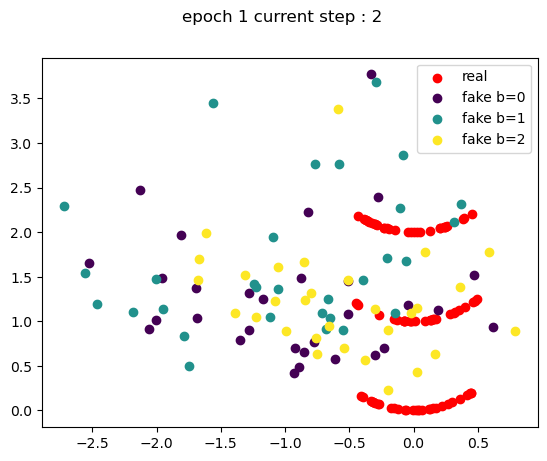

Step 2: Generator loss: 0.03706040605902672, crtic loss: 14.000497817993164
Memory usage (RSS): 359.9375 MB


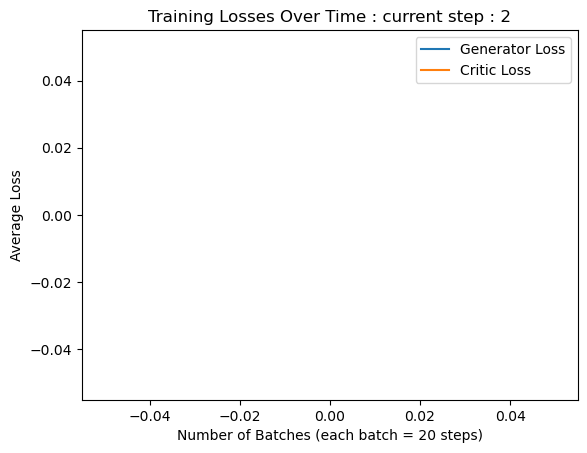

saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/conditionalWGAN_GP.out/img/generated_plot_epoch001.png


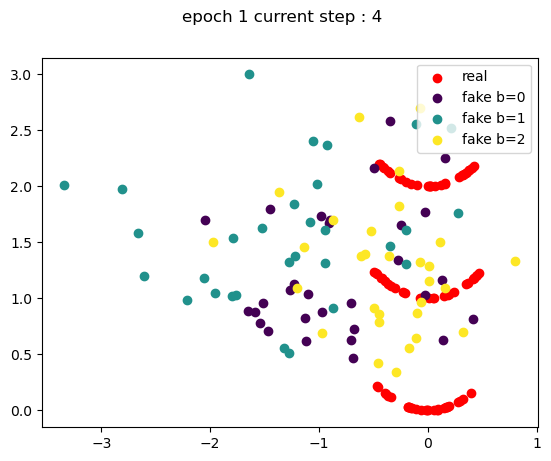

Step 4: Generator loss: 0.03725920058786869, crtic loss: 14.03689193725586
Memory usage (RSS): 361.59375 MB


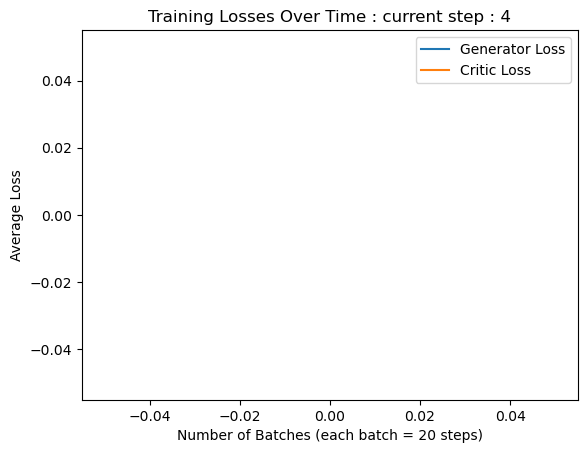

saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/conditionalWGAN_GP.out/img/generated_plot_epoch002.png


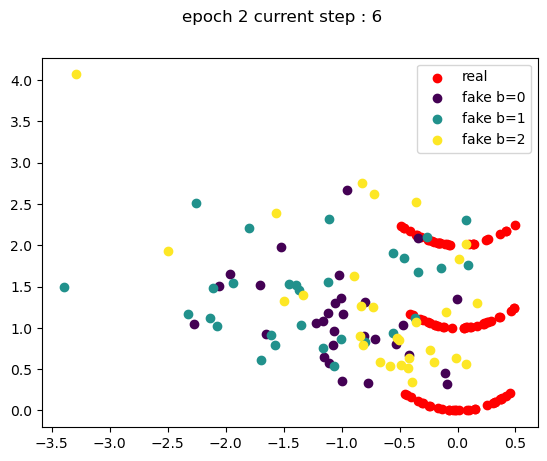

Step 6: Generator loss: 0.03682839497923851, crtic loss: 14.001051425933838
Memory usage (RSS): 363.65625 MB


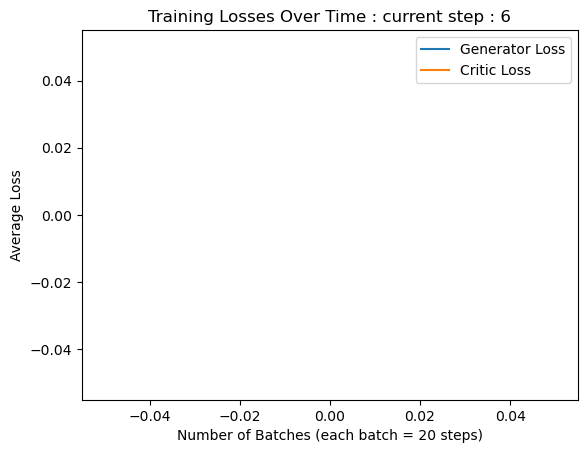

saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/conditionalWGAN_GP.out/img/generated_plot_epoch002.png


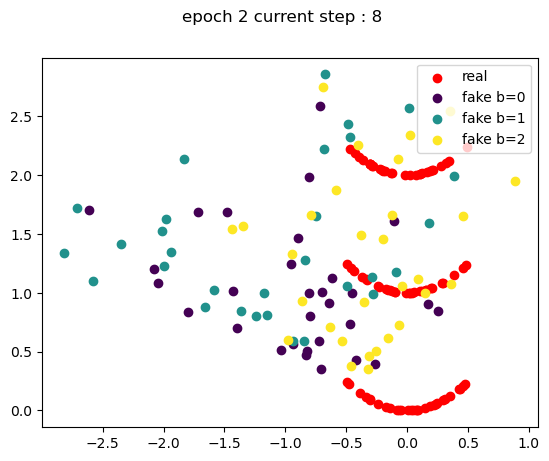

finished
saved : /private/home/aedavids/extraCellularRNA/intraExtraRNA_POC/jupyterNotebooks/elife/gan/conditionalWGAN_GP.out/img/generated_plot_epoch002.png


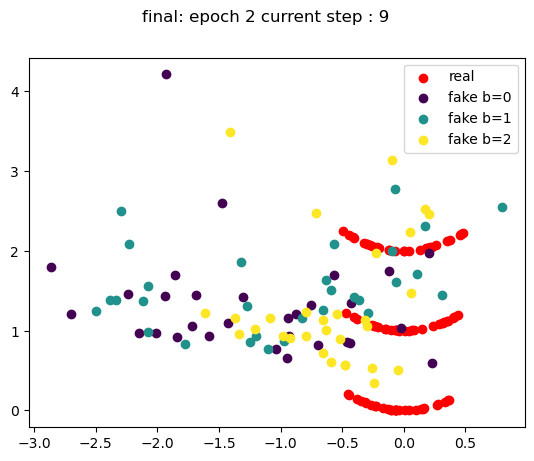

CPU times: user 2.52 s, sys: 87.9 ms, total: 2.61 s
Wall time: 2.59 s


In [23]:
%%time

# reset state every time we run
currentStep = 0


generatorLosses = []
criticLosses = []

testGenerator= True # if true test generator weights are changing
error = False # default: no error

for epoch in range(nEpochs):
    # TODO add check point at end of each epoch    
    
    # tqdm provides progress bars for loops and iterables.
    # will choose implementaiton based on env. ie shell, juypter, ...
    # https://tqdm.github.io/
    # for i in tqdm( range(numBatchs) ) : 
    for i in range(numBatchs) : 
        # each epoch trains using all training samples where each sample is assigned to 
        # a random batch. After each batch update the model weights
        
        # if we where working with real data it is possible 
        # some batches are short. are < batchSize
        currentBatchSize = batchSize
        
        #################        
        ################# Update critic 
        #################        
        meanIterationCriticLoss = 0
        for _ in range( criticRepeats ):
            # update the critic multiple times every time you update the generator This helps 
            # prevent the generator from overpowering the critic. Sometimes, you might see the 
            # reverse, with the generator updated more times than the critic. This depends on 
            # architectural (e.g. the depth and width of the network) and algorithmic 
            # choices (e.g. which loss you're using).

            criticLoss = updateCritic(critic, generator, criticOptimizer,
                                      zDim, currentBatchSize, nCategories)
            
            # Keep track of the average critic loss in this batch
            meanIterationCriticLoss += criticLoss.item() / criticRepeats

        # concatenate the list items
        criticLosses += [meanIterationCriticLoss]

        #################        
        ################# Update generator 
        ################# 
        meanIterationGeneratorLoss = 0
        for _ in range( generatorRepeats ):
            generatorLoss = updateGenerator(critic, generator, generatorOptimizer, 
                                            zDim, currentBatchSize, nCategories)
            # Keep track of the average generators loss in this batch            
            meanIterationGeneratorLoss += generatorLoss.item() / generatorRepeats
    
        generatorLosses += [meanIterationGeneratorLoss]

        # ### Visualization code ###
        if currentStep % displayStep == 0 and currentStep > 0:
            # basic stats
            genMean = sum(generatorLosses[-displayStep:]) / displayStep
            criticMean = sum(criticLosses[-displayStep:]) / displayStep            
            msg = f'Step {currentStep:,}: Generator loss: {genMean}, crtic loss: {criticMean}'
            print( msg )

            # Get memory usage of the current process in bytes
            process = psutil.Process()
            memory_info = process.memory_info()
            rss_memory = memory_info.rss  # Resident Set Size (physical memory used)
            print("Memory usage (RSS):", rss_memory / (1024 * 1024), "MB")   
            
            #
            # plot learning curves
            # 
            plotLearningCurvers( generatorLosses, criticLosses, currentStep )
            
        currentStep += 1

        #if (epoch + 1) % displayQuotient == 0 and currentStep > 0:
        if currentStep % plotStep == 0 and currentStep > 0:
            title = f"epoch {epoch + 1:,} current step : {currentStep:,}"
            summarizePerformance(generator, nCategories, zDim, imgOut, title)
            # TODO debugGAN(currentStep, criticRepeats, generatorRepeats, generator, zDim, currentBatchSize, device)


print(f'finished')
title = f"final: epoch {epoch + 1} current step : {currentStep + 1} "
summarizePerformance(generator, nCategories, zDim, imgOut, title)

In [24]:
# debugGAN(currentStep, criticRepeats, generatorRepeats, generator, zDim, currentBatchSize, device)